# M2608.002900 기계학습 기초 <br> Assignment 1: Logistic Regression

# Setup
Check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn 0.20 or later is installed.

In [13]:
# Python >=3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn >=0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

## Dataset load & Plot

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from warnings import filterwarnings
filterwarnings('ignore')

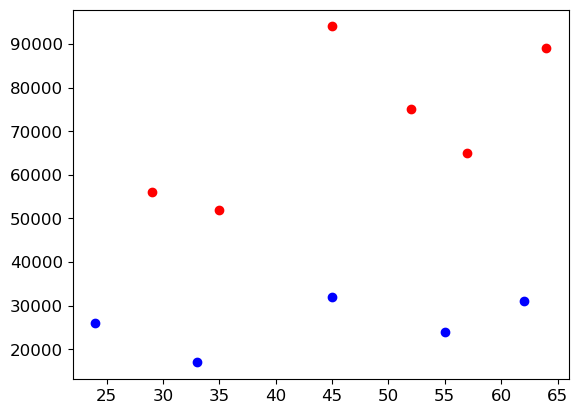

In [15]:
data = np.loadtxt('data.csv', delimiter=',')
X = data[:, :2]
y = data[:, 2]
label_mask = np.equal(y, 1)

plt.scatter(X[:, 0][label_mask], X[:, 1][label_mask], color='red')
plt.scatter(X[:, 0][~label_mask], X[:, 1][~label_mask], color='blue')
plt.show()

## Problem 0-1. sklearn model로 Logistic Regression 모델 train 시켜보기
scikit-learn library의 LogisticRegression 클래스를 이용해 train 시켜 보세요. <br>
클래스 인자 및 사용법에 관한 자세한 설명은 scikit-learn 홈페이지의 설명을 참고해 주세요. <br>
(참고: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

코드 구현에 LLM(Chat-GPT, Gemini, Claude 등)을 보조 도구로 활용하여도 됩니다.

In [16]:
def learn_and_return_weights(X, y):
    from sklearn.linear_model import LogisticRegression
    # YOUR CODE COMES HERE
    lr = LogisticRegression()
    lr.fit(X, y)
    w = lr.coef_[0]
    b = lr.intercept_[0]
    # w: coefficient of the model to input features,
    # b: bias of the model
    return w, b

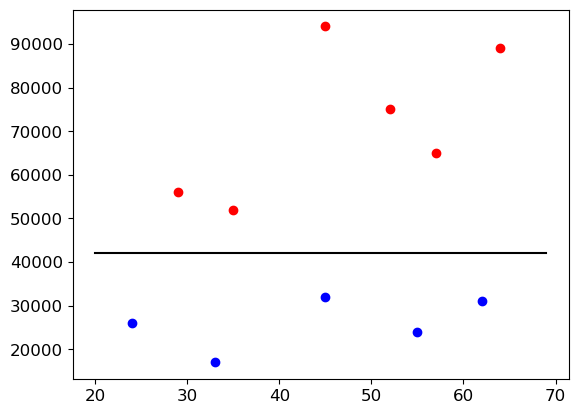

In [17]:
def plot_data_and_weights(X, y, w, b):
    plt.scatter(X[:, 0][label_mask], X[:, 1][label_mask], color='red')
    plt.scatter(X[:, 0][~label_mask], X[:, 1][~label_mask], color='blue')

    x_lin = np.arange(20, 70)
    y_lin = -(b + w[0] * x_lin) / w[1]

    plt.plot(x_lin, y_lin, color='black');
    plt.show()

w, b = learn_and_return_weights(X, y)
plot_data_and_weights(X, y, w, b)

## Problem 0-2. numpy로 Logistic Regression 구현해보기
scikit-learn library를 사용하지 않고 numpy를 활용하여 Logistic Regression을 구현해보세요.

코드 구현에 LLM(Chat-GPT, Gemini, Claude 등)을 보조 도구로 활용하여도 됩니다.

In [18]:
def sigmoid(z):
    # YOUR CODE COMES HERE
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy_loss(y_pred, target):
    # YOUR CODE COMES HERE
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(target * np.log(y_pred) + (1 - target) * np.log(1 - y_pred))
    return loss

def learn_and_return_weights_numpy(X, Y, lr=.01, iter=100000):
    # YOUR CODE COMES HERE
    num_samples, num_features = X.shape
    W = np.zeros(num_features)
    b = 0.0
    for _ in range(iter):
        z = np.dot(X, W) + b
        y_pred = sigmoid(z)
        dw = (1 / num_samples) * np.dot(X.T, (y_pred - Y))
        db = (1 / num_samples) * np.sum(y_pred - Y)
        W -= lr * dw
        b -= lr * db
    # w: coefficient of the model to input features,
    # b: bias of the model
    return W, b

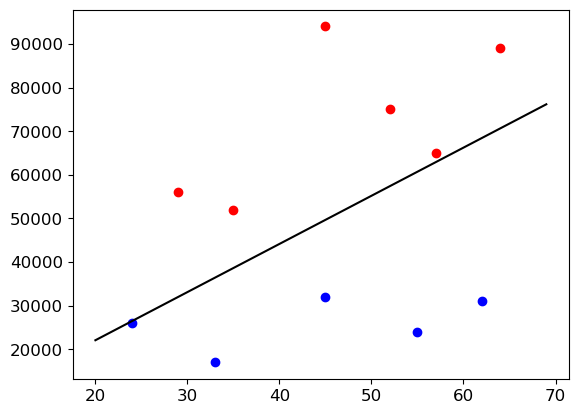

Binary cross entropy loss: 9.992007221626413e-16


In [19]:
w, b = 0, 0
w, b = learn_and_return_weights_numpy(X, y)
plot_data_and_weights(X, y, w, b)

z = np.dot(X, w) + b
y_output = sigmoid(z)
bce = binary_cross_entropy_loss(y_output,y)
if np.isnan(bce) == True:
    print('You need to make sure your binary cross entropy loss function is correct,\nor add a small number (e.g. 1e-10) to the argument of the logarithm to make sure the argument of the logarithm is not zero.')
else:
    print('Binary cross entropy loss:', bce)

## Problem 1-1. Logistic Regression으로 multi-class classification 하기: API 활용하기
scikit-learn library의 Logistic Regression API를 활용하면 multi-class classification을 간단하게 수행할 수 있습니다.<br>
Fashion-MNIST dataset에 대해 multi-class classification을 위한 Logistic Regression 모델을 학습시키고, test data에 대한 accuracy를 계산해 보세요.

* **2개 이상의 LLM을 활용하여 코드를 구현하고, 구현 결과를 비교 분석하여 보고서에 작성하세요.**

In [20]:
def get_dataset():
    from torchvision.datasets import FashionMNIST
    train_data = FashionMNIST(root = './data', train=True, download=True)
    test_data = FashionMNIST(root = './data', train=False, download=True)
    x_train = train_data.data.numpy()
    y_train = train_data.targets.numpy()
    x_test = test_data.data.numpy()
    y_test = test_data.targets.numpy()
    x_train = x_train.reshape((-1, 28 * 28)).astype(np.float32)
    x_test = x_test.reshape((-1, 28 * 28)).astype(np.float32)
    return (x_train, y_train), (x_test, y_test)
(x_train, y_train), (x_test, y_test) = get_dataset()

num_classes = 10

100%|██████████| 26.4M/26.4M [00:17<00:00, 1.48MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 99.1kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 1.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


In [23]:
def learn_mul(X, y):
    ################# YOUR CODE COMES HERE ######################
    # training and return the multi-class logistic model
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X, y)
    #############################################################
    return lr

def inference_mul(x, lr_model):
    ################# YOUR CODE COMES HERE ######################
    # inference model and return predicted y values
    y_pred = lr_model.predict(x)
    #############################################################
    return y_pred

In [24]:
model = learn_mul(x_train, y_train)
preds = inference_mul(x_test, model)
accuracy = np.sum(preds == y_test) / y_test.shape[0]
print('Accuracy:', accuracy)

Accuracy: 0.8316


## Problem 1-2. Logistic Regression으로 multi-class classification 하기: Transformation to Binary (OvR)

Logistic Regression은 기본적으로 binary classifier 입니다. 즉, input *X*를 2개의 class로 밖에 분류하지 못합니다.<br>
하지만, 특정 클래스 하나를 Positive(1)로 두고 **나머지 모든 클래스(Rest)** 를 Negative(0)로 묶어 이진 분류하는 과정을 각 클래스마다 반복하면 data를 여러 class로 분류할 수 있습니다. 이를 **One-vs-Rest (OvR)** 전략이라고 합니다.<br>
(참고: https://en.wikipedia.org/wiki/Multiclass_classification#Transformation_to_binary)

Fashion-MNIST dataset을 이용하여 (class 수) 개의 Binary classifier (Logistic Regression)를 'lrs'의 각 원소에 저장한 뒤,<br>
학습시킨 모델들을 이용하여 test data에 대한 accuracy를 계산해 보세요.<br>
(각 모델의 training iteration은 20회면 충분합니다.)

* **2개 이상의 LLM을 활용하여 코드를 구현하고, 구현 결과를 비교 분석하여 보고서에 작성하세요.**

In [25]:
def learn_ovr(X, y):
    lrs = []
    ordinal = lambda n: "%d%s" % (n,"tsnrhtdd"[(n/10%10!=1)*(n%10<4)*n%10::4])
    for i in range(num_classes):
        print('training %s classifier'%(ordinal(i+1)))
        ################# YOUR CODE COMES HERE ######################
        # training and return the multi-class logistic model
        from sklearn.linear_model import LogisticRegression
        y_binary = (y == i).astype(int)
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X, y_binary)
        lrs.append(lr)
        #############################################################

    return lrs

def inference_ovr(X, lrs):
    ################# YOUR CODE COMES HERE ######################
    # inference model and return predicted y values
    import numpy as np
    X_2d = np.atleast_2d(X) 
    probas = []
    for lr in lrs:
        probas.append(lr.predict_proba(X_2d)[:, 1])
    y_pred = np.argmax(probas, axis=0)
    if np.ndim(X) == 1:
        return y_pred[0]
    #############################################################
    return y_pred

In [26]:
models = learn_ovr(x_train, y_train)
preds = np.array([inference_ovr(x, models) for x in x_test])
accuracy = np.sum(preds == y_test) / y_test.shape[0]
print('Accuracy:', accuracy)

training 1st classifier
training 2nd classifier
training 3rd classifier
training 4th classifier
training 5th classifier
training 6th classifier
training 7th classifier
training 8th classifier
training 9th classifier
training 10th classifier
Accuracy: 0.8353


## Problem 1-3. Logistic Regression으로 multi-class classification 하기: Transformation to Binary (OvO)

OvR(One-vs-Rest) 전략과 달리, OvO(One-vs-One) 전략은 가능한 모든 두 클래스의 조합에 대해 이진 분류기를 학습시킵니다. <br>
클래스가 N개인 경우, 총 $N(N-1)/2$개의 모델을 만들어야 합니다.<br>

Fashion-MNIST dataset을 이용하여 모든 클래스 쌍(pair)에 대한 Binary classifier (Logistic Regression)를 학습시켜 `lrs` 딕셔너리에 저장한 뒤,<br>
학습시킨 모델들이 예측한 결과를 **다수결(Majority Voting)** 로 집계하여 test data에 대한 accuracy를 계산해 보세요.<br>
(각 모델의 training iteration은 20회면 충분합니다.)

* **2개 이상의 LLM을 활용하여 코드를 구현하고, 구현 결과를 비교 분석하여 보고서에 작성하세요.** <br>
* **OvR(1-2)과 OvO(1-3) 두 방법론에 대해 예측 정확도(Accuracy), 총 학습 시간(Time Cost), 그리고 모델 개수 및 데이터 샘플 수에 따른 효율성을 상호 비교하여 분석 보고서를 작성하세요.**

In [27]:
from itertools import combinations
def learn_ovo(X, y):
    lrs = {}
    class_pairs = list(combinations(range(num_classes), 2))
    for i, j in class_pairs:
        print(f'training classifier for class {i} vs {j}')
        ################# YOUR CODE COMES HERE ######################
        # training and return the multi-class logistic model
        from sklearn.linear_model import LogisticRegression
        mask = (y == i) | (y == j)
        X_sub, y_sub = X[mask], y[mask]
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_sub, y_sub)
        lrs[(i, j)] = lr
        #############################################################

    return lrs

def inference_ovo(X, lrs):
    ################# YOUR CODE COMES HERE ######################
    # inference model and return predicted y values
    import numpy as np
    X_2d = np.atleast_2d(X)
    num_classes = max([max(pair) for pair in lrs.keys()]) + 1
    votes = np.zeros((X_2d.shape[0], num_classes))
    for (_, _), lr in lrs.items():
        preds = lr.predict(X_2d).astype(int)
        np.add.at(votes, (np.arange(X_2d.shape[0]), preds), 1)
    y_pred = np.argmax(votes, axis=1)
    if np.ndim(X) == 1:
        return y_pred[0]
     #############################################################
    return y_pred

In [28]:
models = learn_ovo(x_train, y_train)
preds = np.array([inference_ovo(x, models) for x in x_test])
accuracy = np.sum(preds == y_test) / y_test.shape[0]
print('Accuracy:', accuracy)

training classifier for class 0 vs 1
training classifier for class 0 vs 2
training classifier for class 0 vs 3
training classifier for class 0 vs 4
training classifier for class 0 vs 5
training classifier for class 0 vs 6
training classifier for class 0 vs 7
training classifier for class 0 vs 8
training classifier for class 0 vs 9
training classifier for class 1 vs 2
training classifier for class 1 vs 3
training classifier for class 1 vs 4
training classifier for class 1 vs 5
training classifier for class 1 vs 6
training classifier for class 1 vs 7
training classifier for class 1 vs 8
training classifier for class 1 vs 9
training classifier for class 2 vs 3
training classifier for class 2 vs 4
training classifier for class 2 vs 5
training classifier for class 2 vs 6
training classifier for class 2 vs 7
training classifier for class 2 vs 8
training classifier for class 2 vs 9
training classifier for class 3 vs 4
training classifier for class 3 vs 5
training classifier for class 3 vs 6
t

## Problem 2. Logistic Regression을 활용한 임의의 데이터셋 분류 실습

**이번 문제에서는 Pima Indians Diabetes dataset을 활용하여 분류를 실습해볼 것입니다.** 이 데이터셋은 UCI Machine Learning Repository에서 제공했으며, 21세 이상의 피마 인디언 혈통 여성 환자들로부터 수집되었습니다.

임신 횟수(Pregnancies), 혈장 포도당 농도(Glucose), 이완기 혈압(BloodPressure), 삼두근 피부 두께(SkinThickness), 인슐린(Insulin), 체질량 지수(BMI) 등 다양한 생체 지표를 바탕으로 환자의 당뇨병 발병 여부를 logistic regression 알고리즘으로 분류하고 예측해 보겠습니다. 데이터셋에 대한 추가적인 설명은 아래 링크를 참조하세요.
(참고: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database/data)

앞의 실습 내용들을 참고하여 numpy로 여러 변수에 대한 logistic regression을 구현하세요.  
LLM을 도구로 활용하여 구현하여도 괜찮습니다.  

* **수업 시간에 배운 logistic regression의 성능을 올리기 위한 여러 방식들을 활용하여 최대한 성능을 높여보세요.**  
    (ex. L1, L2 regularization, polynomial features 등)
* **성능 향상을 위해 사용한 전략이나 구현한 핵심 함수에 대해 보고서에 작성하세요.**

In [29]:
################################### Dataset Preprocessing #############################################
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

data = fetch_openml('diabetes', version=1, as_frame=True, parser='auto')

df = data.data.copy()
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
               'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
df['target'] = (data.target == 'tested_positive').astype(int)

# Replace invalid zeros with NaN, then impute with median
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

print(df.head())

X = df.drop(columns=['target'])
y = df['target']

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigree  Age  target  
0             0.627   50       1  
1             0.351   31       0  
2             0.672   32       1  
3             0.167   21       0  
4             2.288   33       1  


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')


X_train[zero_cols] = imputer.fit_transform(X_train[zero_cols])
X_test[zero_cols] = imputer.transform(X_test[zero_cols]) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
import numpy as np
from sklearn.metrics import accuracy_score

class LogisticRegression:
    def __init__(self, learning_rate=0.001, num_iterations=2000, lambda_param=1.0, poly_degree=2): # <<< You can add your own input parameters
        ################# YOUR CODE COMES HERE ######################
        # initialize class member variable
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.lambda_param = lambda_param
        self.poly_degree = poly_degree
        self.weights = None
        self.bias = None
        #############################################################

    def sigmoid(self, z):
        # YOUR CODE COMES HERE
        import numpy as np
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        ################# YOUR CODE COMES HERE ######################
        # training model here
        import numpy as np
        def add_poly_features(X_in):
            if self.poly_degree < 2:
                return X_in
            features = [X_in]
            n = X_in.shape[1]
            for i in range(n):
                for j in range(i, n):
                    features.append((X_in[:, i] * X_in[:, j]).reshape(-1, 1))
            return np.hstack(features)
        X = add_poly_features(X)
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
        # Adam optimizer state
        m_w = np.zeros(num_features)
        v_w = np.zeros(num_features)
        m_b = 0.0
        v_b = 0.0
        beta1, beta2, epsilon = 0.9, 0.999, 1e-8
        for t in range(1, self.num_iterations + 1):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y)) + (self.lambda_param / num_samples) * self.weights
            db = (1 / num_samples) * np.sum(y_predicted - y)
            # Adam moment updates
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw ** 2)
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db ** 2)
            # Bias-corrected estimates
            m_w_hat = m_w / (1 - beta1 ** t)
            v_w_hat = v_w / (1 - beta2 ** t)
            m_b_hat = m_b / (1 - beta1 ** t)
            v_b_hat = v_b / (1 - beta2 ** t)
            self.weights -= self.learning_rate * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
            self.bias -= self.learning_rate * m_b_hat / (np.sqrt(v_b_hat) + epsilon)
        #############################################################
        return

    def predict(self, X):
        ################# YOUR CODE COMES HERE ######################
        # return predicted y
        import numpy as np

        def add_poly_features(X_in):
            if self.poly_degree < 2:
                return X_in
            features = [X_in]
            n = X_in.shape[1]
            for i in range(n):
                for j in range(i, n):
                    features.append((X_in[:, i] * X_in[:, j]).reshape(-1, 1))
            return np.hstack(features)

        X = add_poly_features(X)
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = np.where(y_predicted > 0.5, 1, 0)
        #############################################################
        return y_predicted_cls

    # You can add your own member functions

model = LogisticRegression( ) ##### ADD YOUR OWN INPUT PARAMETERS

# Train and predict the model
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7662
